In [10]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
#1. Load the BERT model (pre-trained for sentiment analysis) with its tokenizer
#here, we use the distilled (smaller) version of BERT model
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, output_attentions=True)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 11529.21it/s]


In [3]:
#2. Prepare the input
text = "The acting was incredible, but the script was absolutely terrible."
inputs = tokenizer(text, return_tensors="pt",truncation=True, max_length=512) #truncation and max_length: for handling BERT limits for longer inputs
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

In [4]:
#3. Forward pass
with torch.no_grad():
    outputs = model(**inputs)
    attentions = outputs.attentions

In [5]:
#4. Get the sentiment prediction
logits = outputs.logits
probs = F.softmax(logits, dim=-1)
prediction_idx = torch.argmax(probs).item()
label = model.config.id2label[prediction_idx]
confidence = probs[0][prediction_idx].item()
print(f"Sentiment: {label}")
print(f"Confidence: {confidence:.2%}")

Sentiment: NEGATIVE
Confidence: 98.40%


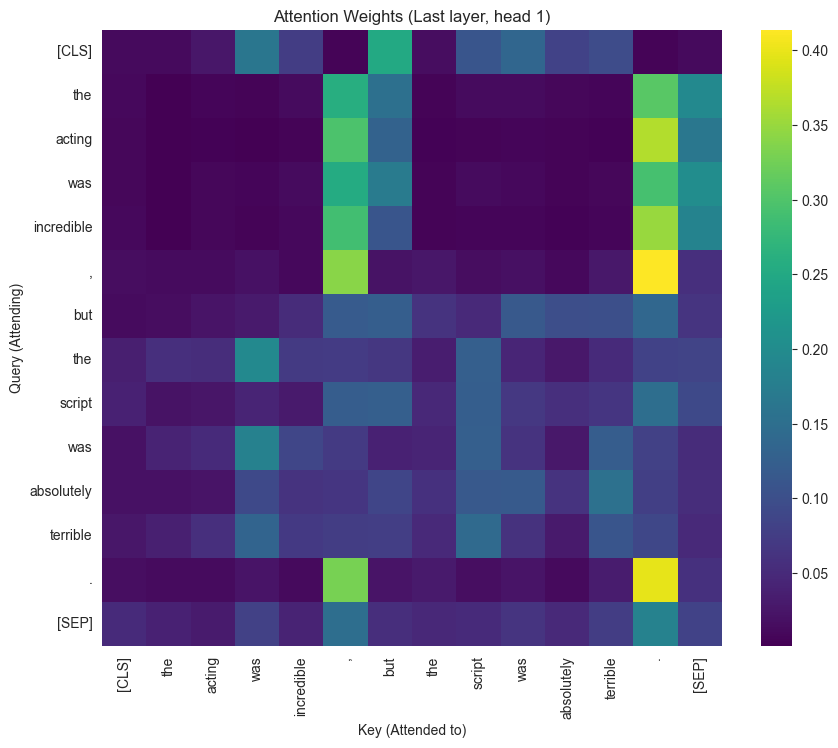

In [6]:
#5. Visualize the attention weights from last layer, first head

head = 0 #0,...,11
attention_matrix = attentions[-1][0, head].detach().numpy() #-1 denotes the last layer (distilbert has 6 layers, 12 heads)

plt.figure(figsize=(10, 8))
sns.heatmap(attention_matrix, xticklabels=tokens, yticklabels=tokens,
            annot=False, cmap="viridis")
plt.title(f"Attention Weights (Last layer, head {head+1})")
plt.xlabel("Key (Attended to)")
plt.ylabel("Query (Attending)")
plt.show()
#We look at the values in the first row (to which tokens does the [CLS] token attend the most)

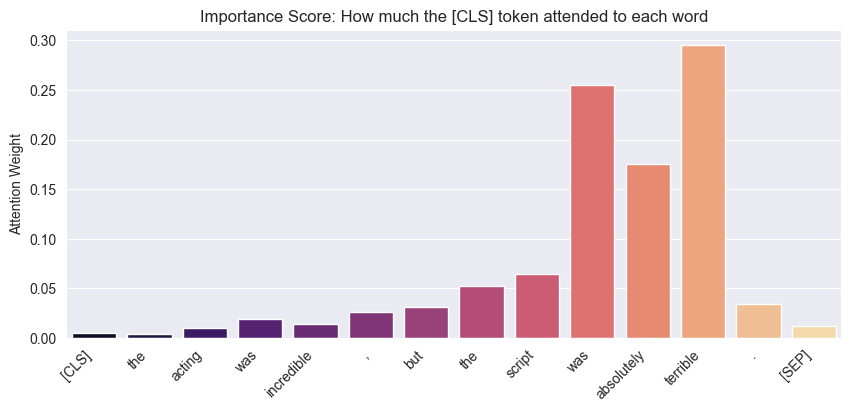

In [7]:
#6. Calculate average attention for [CLS] token and all heads
last_layer = attentions[-1][0]
avg_attn = last_layer.mean(dim=0)
cls_attention = avg_attn[0].detach().numpy()

plt.figure(figsize=(10, 4))
x_pos = range(len(tokens))
sns.barplot(x=x_pos, y=cls_attention, palette="magma")
plt.title("Importance Score: How much the [CLS] token attended to each word")
plt.xticks(x_pos, tokens, rotation=45, ha="right")
plt.ylabel("Attention Weight")
plt.show()

In [8]:
#7. quick IMDb example
imdb_test = load_dataset("imdb", split="test")

In [9]:
review = imdb_test[2] #a single review: text and label
review

{'text': "its a totally average film with a few semi-alright action sequences that make the plot seem a little better and remind the viewer of the classic van dam films. parts of the plot don't make sense and seem to be added in to use up time. the end plot is that of a very basic type that doesn't leave the viewer guessing and any twists are obvious from the beginning. the end scene with the flask backs don't make sense as they are added in and seem to have little relevance to the history of van dam's character. not really worth watching again, bit disappointed in the end production, even though it is apparent it was shot on a low budget certain shots and sections in the film are of poor directed quality",
 'label': 0}